# Imports

In [1]:
import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 📦 Data Loading

We load the curated transaction dataset generated and processed in AWS.

In [2]:
files = glob.glob("enriched_transactions/*.parquet")
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

df.head()

,transaction_id,transaction_datetime,client_id,gender,age_group,client_city,client_province,client_region,store_id,store_name,...,store_region,product_id,product_name,category_level_0,category_level_1,brand,house_brand,quantity,unit_price,total_amount
0,16,2025-09-30 18:05:23,97323,Male,25_34,Charleroi,Hainaut,Wallonia,13,Kaminski Charleroi,...,Wallonia,4738,Kaminski Chicken 4738,Food,Meat,Kaminski,True,1,2.59,2.59
1,16,2025-09-30 18:05:23,97323,Male,25_34,Charleroi,Hainaut,Wallonia,13,Kaminski Charleroi,...,Wallonia,7963,Lay's Chocolate 7963,Food,Snacks,Lay's,False,2,1.16,2.32
2,24,2025-09-19 17:16:25,53281,Male,18_24,Ghent,East Flanders,Flanders,3,Kaminski Ghent,...,Flanders,8316,Kaminski GreenTea 8316,Drinks,Coffee_Tea,Kaminski,True,1,5.35,5.35
3,24,2025-09-19 17:16:25,53281,Male,18_24,Ghent,East Flanders,Flanders,3,Kaminski Ghent,...,Flanders,2638,Lipton Tea 2638,Drinks,Coffee_Tea,Lipton,False,1,9.61,9.61
4,32,2025-09-04 11:04:45,29496,Male,25_34,Tournai,Hainaut,Wallonia,15,Kaminski Tournai,...,Wallonia,7527,Kaminski DishSoap 7527,Household,Cleaning,Kaminski,True,3,6.04,18.12


# 🔍 Data Overview

Quick sanity checks on the dataset structure.

In [3]:
df.shape

(729194, 22)

In [4]:
df.columns.tolist()

['transaction_id',
 'transaction_datetime',
 'client_id',
 'gender',
 'age_group',
 'client_city',
 'client_province',
 'client_region',
 'store_id',
 'store_name',
 'store_city',
 'store_province',
 'store_region',
 'product_id',
 'product_name',
 'category_level_0',
 'category_level_1',
 'brand',
 'house_brand',
 'quantity',
 'unit_price',
 'total_amount']

# 🧺 Basket-Level Features

We aggregate transactions at the basket level (one basket = one transaction).

In [5]:
basket_features = (
    df.groupby(["client_id", "transaction_id"])
      .agg(
          basket_value=("total_amount", "sum"),
          basket_quantity=("quantity", "sum"),
          basket_distinct_products=("product_id", "nunique")
      )
      .reset_index()
)

# 👤 Client-Level Features

We aggregate all baskets to compute customer-level metrics.

In [6]:
client_features = (
    df.groupby("client_id")
      .agg(
          total_spend=("total_amount", "sum"),
          total_lines=("transaction_id", "count"),
          n_transactions=("transaction_id", "nunique"),
          total_quantity=("quantity", "sum"),
          distinct_products=("product_id", "nunique"),
          distinct_cat_lvl0=("category_level_0", "nunique"),
          distinct_cat_lvl1=("category_level_1", "nunique"),
          house_brand_ratio=("house_brand", "mean")
      )
      .reset_index()
)

# 📊 Basket Behavior Features

We compute average basket behavior per customer.

In [7]:
basket_agg = (
    basket_features.groupby("client_id")
    .agg(
        avg_basket_value=("basket_value", "mean"),
        avg_basket_quantity=("basket_quantity", "mean"),
        avg_distinct_products_per_basket=("basket_distinct_products", "mean")
    )
    .reset_index()
)

client_features = client_features.merge(basket_agg, on="client_id", how="left")

# 🏷️ Favorite Category

We identify each customer's most purchased category.

In [8]:
fav_cat = (
    df.groupby(["client_id", "category_level_0"])["total_amount"]
      .sum()
      .reset_index()
      .sort_values(["client_id", "total_amount"], ascending=[True, False])
      .drop_duplicates("client_id")
      .rename(columns={"category_level_0": "favorite_category"})
      [["client_id", "favorite_category"]]
)

client_features = client_features.merge(fav_cat, on="client_id", how="left")

# 👥 Demographics

We add demographic information to each customer.

In [9]:
client_demo = (
    df[["client_id", "gender", "age_group", "client_city", "client_province", "client_region"]]
    .drop_duplicates(subset=["client_id"])
)

client_features = client_features.merge(client_demo, on="client_id", how="left")

# 🧼 Data Quality Check

Ensure there are no missing values before clustering.

In [10]:
client_features.isna().sum()

client_id                           0
total_spend                         0
total_lines                         0
n_transactions                      0
total_quantity                      0
distinct_products                   0
distinct_cat_lvl0                   0
distinct_cat_lvl1                   0
house_brand_ratio                   0
avg_basket_value                    0
avg_basket_quantity                 0
avg_distinct_products_per_basket    0
favorite_category                   0
gender                              0
age_group                           0
client_city                         0
client_province                     0
client_region                       0
dtype: int64

# ⚙️ Feature Selection

We select numerical features for clustering.

In [11]:
segmentation_df = client_features[[
    "client_id",
    "total_spend",
    "n_transactions",
    "total_quantity",
    "distinct_products",
    "distinct_cat_lvl0",
    "distinct_cat_lvl1",
    "house_brand_ratio",
    "avg_basket_value",
    "avg_basket_quantity",
    "avg_distinct_products_per_basket"
]].copy()

# 📏 Scaling

We standardize features to ensure fair clustering.

In [12]:
X = segmentation_df.drop(columns="client_id")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 📉 Choosing Number of Clusters (Elbow Method)

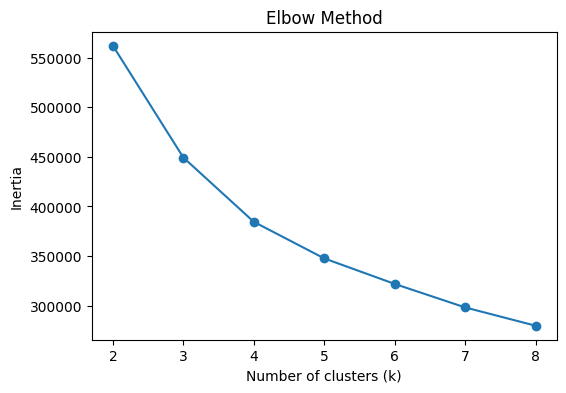

In [13]:
inertias = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2, 9), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# 🤖 KMeans Clustering

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
segmentation_df["cluster"] = kmeans.fit_predict(X_scaled)

In [15]:
# Attaching cluster to full dataset
client_features = client_features.merge(
    segmentation_df[["client_id", "cluster"]],
    on="client_id",
    how="left"
)

# 📊 Cluster Summary

In [16]:
# Favorite category per cluster 
client_features.groupby("cluster")["favorite_category"] \
    .agg(lambda x: x.value_counts().index[0])

cluster
0    Food
1    Food
2    Food
3    Food
Name: favorite_category, dtype: str

In [17]:
# Age group per cluster 
client_features.groupby("cluster")["age_group"] \
    .agg(lambda x: x.value_counts().index[0])

cluster
0    25_34
1    35_44
2    25_34
3    25_34
Name: age_group, dtype: str

# 📈 Cluster Visualization

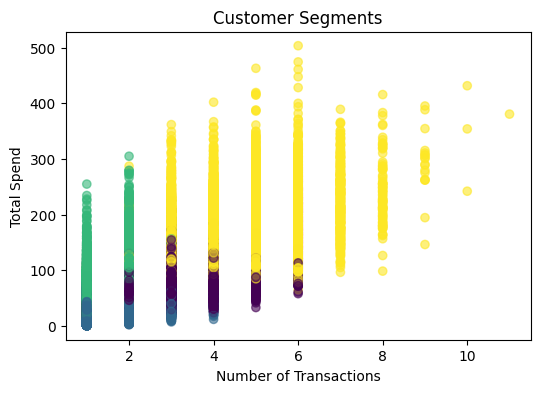

In [18]:
# Visual checking 
plt.figure(figsize=(6,4))

plt.scatter(
    client_features["n_transactions"],
    client_features["total_spend"],
    c=client_features["cluster"],
    alpha=0.6
)

plt.xlabel("Number of Transactions")
plt.ylabel("Total Spend")
plt.title("Customer Segments")
plt.show()

In [19]:
cluster_summary = (
    client_features.groupby("cluster")
    .agg(
        clients=("client_id", "count"),
        avg_spend=("total_spend", "mean"),
        avg_transactions=("n_transactions", "mean"),
        avg_quantity=("total_quantity", "mean"),
        avg_distinct_products=("distinct_products", "mean"),
        avg_house_brand_ratio=("house_brand_ratio", "mean"),
        avg_basket=("avg_basket_value", "mean"),
        avg_basket_quantity=("avg_basket_quantity", "mean"),
        avg_distinct_products_per_basket=("avg_distinct_products_per_basket", "mean")
    )
    .round(2)
)

cluster_summary.sort_values("avg_spend", ascending=False)

,clients,avg_spend,avg_transactions,avg_quantity,avg_distinct_products,avg_house_brand_ratio,avg_basket,avg_basket_quantity,avg_distinct_products_per_basket
cluster,,,,,,,,,
3,15070,160.56,4.16,29.56,16.98,0.36,40.09,7.32,4.18
2,17059,75.73,1.44,13.44,7.26,0.35,53.28,9.47,5.14
0,27214,75.46,2.75,15.02,9.29,0.36,28.31,5.61,3.47
1,27015,26.28,1.41,5.49,3.57,0.36,19.15,4.00,2.59


# 🧠 Cluster Interpretation

- **Cluster 0** → Low engagement customers
    > *Low spend, low transaction frequency, and small basket sizes.*
- **Cluster 1** → Occasional customers
    > *Low transaction frequency with moderate basket sizes.*
- **Cluster 2** → Bulk buyers
    > *Low transaction frequency but large baskets and high quantities per purchase.*
- **Cluster 3** → High-value customers
    > *High spend, high transaction frequency, and strong overall engagement.*
  
These segments can be used for targeted marketing strategies.